## Today's topics

- ANNOVA Test
- Test Implementation of continuous data

---


# 🔹 What is ANOVA?

ANOVA is used to compare the means of **three or more groups**.

H₀: μ₁ = μ₂ = μ₃  
H₁: At least one group mean is different


ANOVA uses the **F-distribution**.


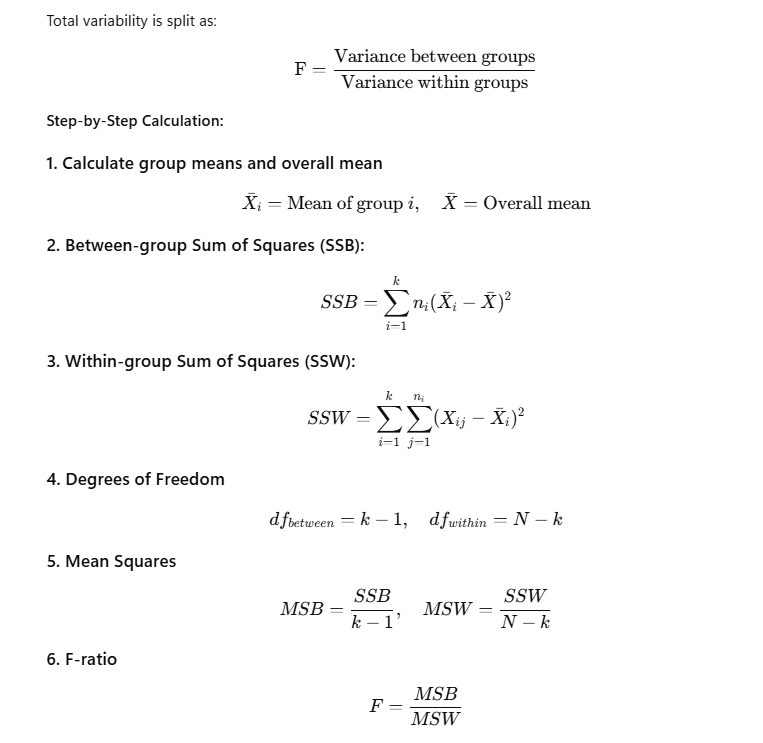


# 🔹 Real-World Example: Teaching Methods

Compare average scores of students from 3 different teaching methods.

Are their means significantly different?


In [1]:

import numpy as np

method_A = np.array([78, 82, 80, 79])
method_B = np.array([85, 87, 84, 86])
method_C = np.array([88, 90, 92, 89])

method_A, method_B, method_C


(array([78, 82, 80, 79]), array([85, 87, 84, 86]), array([88, 90, 92, 89]))


# 🔹 Manual ANOVA Calculation


In [2]:

groups = [method_A, method_B, method_C]

all_data = np.concatenate(groups)
grand_mean = np.mean(all_data)

SSB = sum(len(g) * (np.mean(g) - grand_mean)**2 for g in groups)
SSW = sum(sum((g - np.mean(g))**2) for g in groups)

# out = []

# for g in groups:
#   out.append(len(g) * (np.mean(g) - grand_mean)**2)

# ssb = sum(out)

k = len(groups)
N = len(all_data)

df_between = k - 1
df_within = N - k

MSB = SSB / df_between
MSW = SSW / df_within

F_statistic = MSB / MSW

F_statistic


40.3


# 🔹 Automated ANOVA using scipy


In [3]:

from scipy import stats

F_auto, p_value = stats.f_oneway(method_A, method_B, method_C)

F_auto, p_value


(40.3, 3.2263037207958414e-05)


# 🔹 Critical F-value


In [4]:

from scipy import stats

alpha = 0.05
critical_F = stats.f.ppf(1 - alpha, df_between, df_within)

F_statistic, p_value, critical_F


(40.3, 3.2263037207958414e-05, 4.25649472909375)


# 🧪 Method-1: p-value approach


In [5]:

if p_value < alpha:
    print("The p-value is less than 0.05, so we reject the null hypothesis. At least one teaching method differs significantly.")
else:
    print("The p-value is greater than or equal to 0.05, so we fail to reject the null hypothesis. No significant difference among methods.")


The p-value is less than 0.05, so we reject the null hypothesis. At least one teaching method differs significantly.



# 🧪 Method-2: Critical Value approach


In [6]:

if F_statistic > critical_F:
    print("The F-statistic falls outside the decision boundary, so we reject the null hypothesis. At least one method performs differently.")
else:
    print("The F-statistic falls within the decision boundary, so we fail to reject the null hypothesis. Methods perform similarly.")


The F-statistic falls outside the decision boundary, so we reject the null hypothesis. At least one method performs differently.



# 🔹 Visualization of Group Means


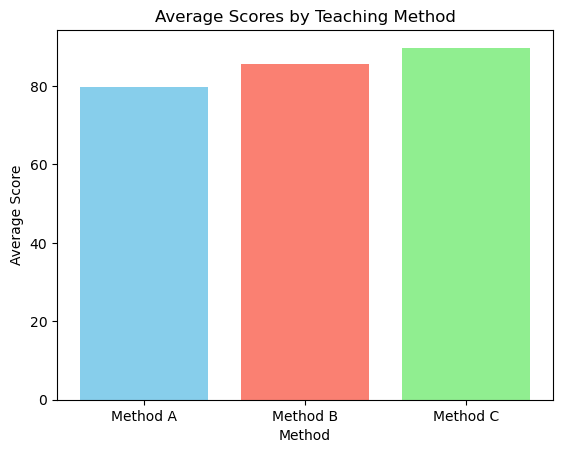

In [10]:

import matplotlib.pyplot as plt

means = [np.mean(method_A), np.mean(method_B), np.mean(method_C)]

plt.bar(["Method A", "Method B", "Method C"], means,color=['skyblue', 'salmon', 'lightgreen'])
plt.title("Average Scores by Teaching Method")
plt.xlabel("Method")
plt.ylabel("Average Score")
plt.show()



## 📝 Practice Questions
1. When to use ANOVA Test?
2. Explain types of all three ANOVA Tests with formulas.
3. Difference between one-way and two-way ANOVA Test.



## 📌 Mini Assignment

A company tests 3 marketing campaigns.

Campaign A: [45, 48, 50, 47]  
Campaign B: [52, 55, 53, 54]  
Campaign C: [60, 58, 62, 59]

Tasks:
1. State H₀ and H₁
2. Perform manual ANOVA
3. Use f_oneway()
4. Compute critical F-value
5. Apply both decision methods
6. Interpret business meaning


F-statistic: 50.4953, Critical F-value: 4.2565
F-statistic (scipy): 50.4953, p-value: 0.0000
The p-value is less than 0.05, so we reject the null hypothesis. At least one campaign differs significantly.
The F-statistic falls outside the decision boundary, so we reject the null hypothesis. At least one campaign performs differently.


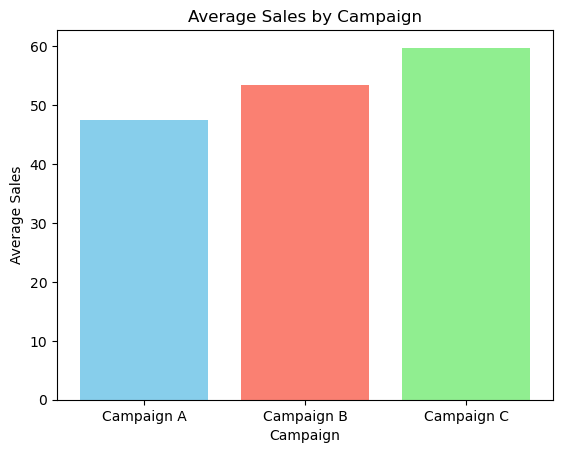

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

compaingn_A = np.array([45,48,50,47])
compaingn_B = np.array([52,55,53,54])
compaingn_C = np.array([60,58,62,59])

groups = [compaingn_A, compaingn_B, compaingn_C]
all_data = np.concatenate(groups)
grand_mean = np.mean(all_data)

SSB = sum(len(g) * (np.mean(g) - grand_mean)**2 for g in groups)
SSW = sum(sum((g - np.mean(g))**2) for g in groups)

k = len(groups)
N = len(all_data)
df_between = k - 1
df_within = N - k

MSB = SSB / df_between
MSW = SSW / df_within
F_statistic = MSB / MSW
alpha = 0.05
critical_F = stats.f.ppf(1 - alpha, df_between, df_within)

print(f"F-statistic: {F_statistic:.4f}, Critical F-value: {critical_F:.4f}")

F_auto, p_value = stats.f_oneway(compaingn_A, compaingn_B, compaingn_C)
print(f"F-statistic (scipy): {F_auto:.4f}, p-value: {p_value:.4f}")
if p_value < alpha:
    print("The p-value is less than 0.05, so we reject the null hypothesis. At least one campaign differs significantly.")
else:
    print("The p-value is greater than or equal to 0.05, so we fail to reject the null hypothesis. No significant difference among campaigns.")
if F_statistic > critical_F:
    print("The F-statistic falls outside the decision boundary, so we reject the null hypothesis. At least one campaign performs differently.")
else:
    print("The F-statistic falls within the decision boundary, so we fail to reject the null hypothesis. Campaigns perform similarly.")
    
means = [np.mean(compaingn_A), np.mean(compaingn_B), np.mean(compaingn_C)]
plt.bar(["Campaign A", "Campaign B", "Campaign C"], means, color=['skyblue', 'salmon', 'lightgreen'])
plt.title("Average Sales by Campaign")
plt.xlabel("Campaign")
plt.ylabel("Average Sales")
plt.show()
